<a href="https://colab.research.google.com/github/rx1mondo/Newton-Raphson-root-finding-method-using-Matplotib-and-calculus/blob/main/Newton_Raphson_Root_Finding_Visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---Iteration Log---
step1: x=2.360000, f(x)=3.42425600
step2: x=2.127197, f(x)=0.37109985
step3: x=2.095136, f(x)=0.00652663
step4: x=2.094552, f(x)=0.00000215
step5: x=2.094551, f(x)=0.00000000

Converged to root: x = 2.094551 in 5 steps.


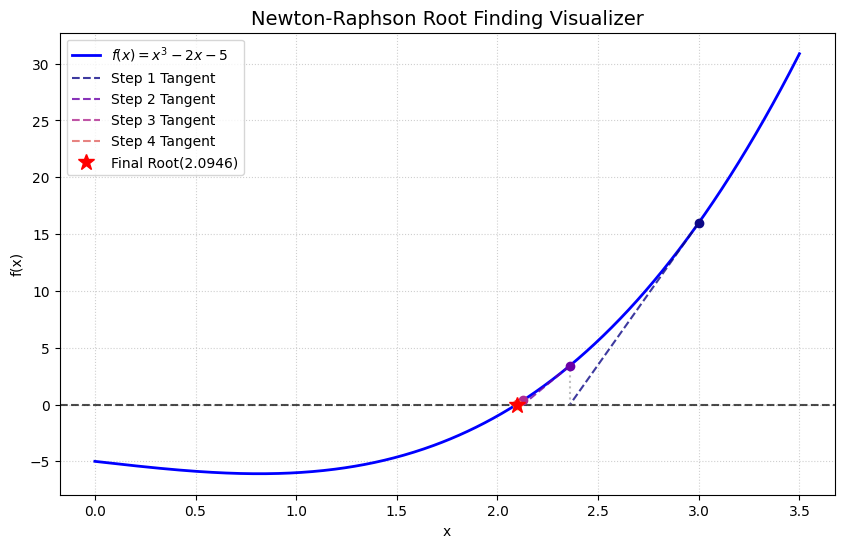

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x**3-2*x-5   #defines mathematical equation

def df(x):
  # Correct derivative of f(x) = x^3 - 2x - 5 is 3x^2 - 2
  return 3*x**2 - 2      #defines derivative of function f(x)

#Newton-Raphson configuration
x_guess=3.0           #initial starting guess
tolerance=1e-6        #accuracy threshold
max_steps=10          #safety cap on functions which do not converge

guesses = [x_guess]   #stores guesses for visualization

print("---Iteration Log---")
for step in range(max_steps):
  y_val=f(x_guess)    #evaluates curves height at guess point
  slope=df(x_guess)   #evaluates gradient at guess point

  # Check for division by zero (slope close to zero)
  if abs(slope) < 1e-9:
      print(f"\nWarning: Slope is near zero at x = {x_guess:.6f}. Cannot proceed with Newton-Raphson.")
      break

  #Newton Raphson formula
  x_next=x_guess-(y_val/slope)
  guesses.append(x_next)

  print(f"step{step+1}: x={x_next:.6f}, f(x)={f(x_next):.8f}")   #shows the current x value and how close f(x) is to 0

  if abs(x_next-x_guess) < tolerance:
    print(f"\nConverged to root: x = {x_next:.6f} in {step + 1} steps.")
    break # Corrected syntax for break statement

  x_guess = x_next     #using newly calculated value prepares the variable for next loop cycle so next tangent line starts from new point


x_plot=np.linspace(0,3.5,500)    #creates an array of 500 evenly spaced numbers from 0-3.5
y_plot=f(x_plot)

plt.figure(figsize=(10,6))     #sets up plot 10inches wide by 6 inches high
plt.plot(x_plot,y_plot,label="$f(x)=x^3-2x-5$",color="blue",linewidth=2)   #draws the main smooth curve of f(x)
plt.axhline(0,color="black",linestyle="--",alpha=0.7)  #shows where f(x)=0

colors=plt.cm.plasma(np.linspace(0,1,len(guesses))) # Corrected pplt to plt

for i in range(len(guesses)-1):   #loops all stored guesses history steps # Corrected fori to for i
  x_curr=guesses[i]
  y_curr=f(x_curr)
  x_next=guesses[i+1]   #gives the exact endpoints needed to draw each individual tangent line segment


# Draw tangent line from (x_curr, y_curr) down to (x_next, 0)
  plt.plot([x_curr, x_next], [y_curr, 0], "--", color=colors[i], alpha=0.8,   #draws tangent line from (x_curr,y_curr) down to (x_next,0)
           label=f"Step {i+1} Tangent" if i < 4 else "")
  plt.plot([x_next, x_next], [0, f(x_next)], ":", color="gray", alpha=0.5)    #draws a vertical drop line to show new guess evaluations on f(x)
  plt.plot(x_curr, y_curr, "o", color=colors[i])    #makes current guess point

plt.plot(guesses[-1],f(guesses[-1]),"r*",markersize=12,label=f"Final Root({guesses[-1]:.4f})")  #plots red star at the final converged coordinate

plt.title("Newton-Raphson Root Finding Visualizer",fontsize=14)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()